In [30]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root so `meta/tools/plot_utils.py` and `.local/euler.csv` work regardless of CWD.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "meta" / "tools" / "plot_utils.py").exists():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("Could not locate repo root containing meta/tools/plot_utils.py")
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "meta" / "tools"))
import plot_utils as pu  # noqa: E402

In [31]:
CSV_PATH = REPO_ROOT / ".local" / "euler.csv"

raw = pd.read_csv(CSV_PATH)
raw["Datetime"] = pd.to_datetime(raw["Datetime"], errors="coerce")
raw = raw.dropna(subset=["Datetime"])

# Drop the aggregate "gpu" row; keep per-model rows only.
per_model = raw[raw["name"] != "gpu"]

available_wide = (
    per_model.pivot_table(
        index="Datetime", columns="name", values="available", aggfunc="mean"
    )
    .sort_index()
)
total_wide = (
    per_model.pivot_table(
        index="Datetime", columns="name", values="total", aggfunc="mean"
    )
    .sort_index()
)

# Normalize each layer by the cluster-wide capacity at that timestamp so the
# stacked total equals the fraction of cluster capacity that is available.
cluster_capacity = total_wide.sum(axis=1)
wide = available_wide.div(cluster_capacity, axis=0).reset_index()
wide.head()

name,Datetime,nvidia_a100-pcie-40gb,nvidia_a100_80gb_pcie,nvidia_geforce_rtx_2080_ti,nvidia_geforce_rtx_3090,nvidia_geforce_rtx_4090,quadro_rtx_6000,tesla_v100-sxm2-32gb
0,2025-07-16 04:12:37,0.004113,0.004113,0.117509,0.053467,0.022914,0.030552,0.007638
1,2025-07-16 04:20:46,0.004113,0.004113,0.118096,0.053467,0.023502,0.030552,0.009988
2,2025-07-16 05:00:03,0.004700,0.005288,0.119859,0.053467,0.022914,0.025852,0.009988
3,2025-07-16 06:00:04,0.000588,0.008813,0.120447,0.054054,0.022914,0.026439,0.009988
4,2025-07-16 07:00:07,0.000588,0.007051,0.116921,0.054054,0.022914,0.022914,0.009988


Saved figure: figure/gpu_availability.pdf


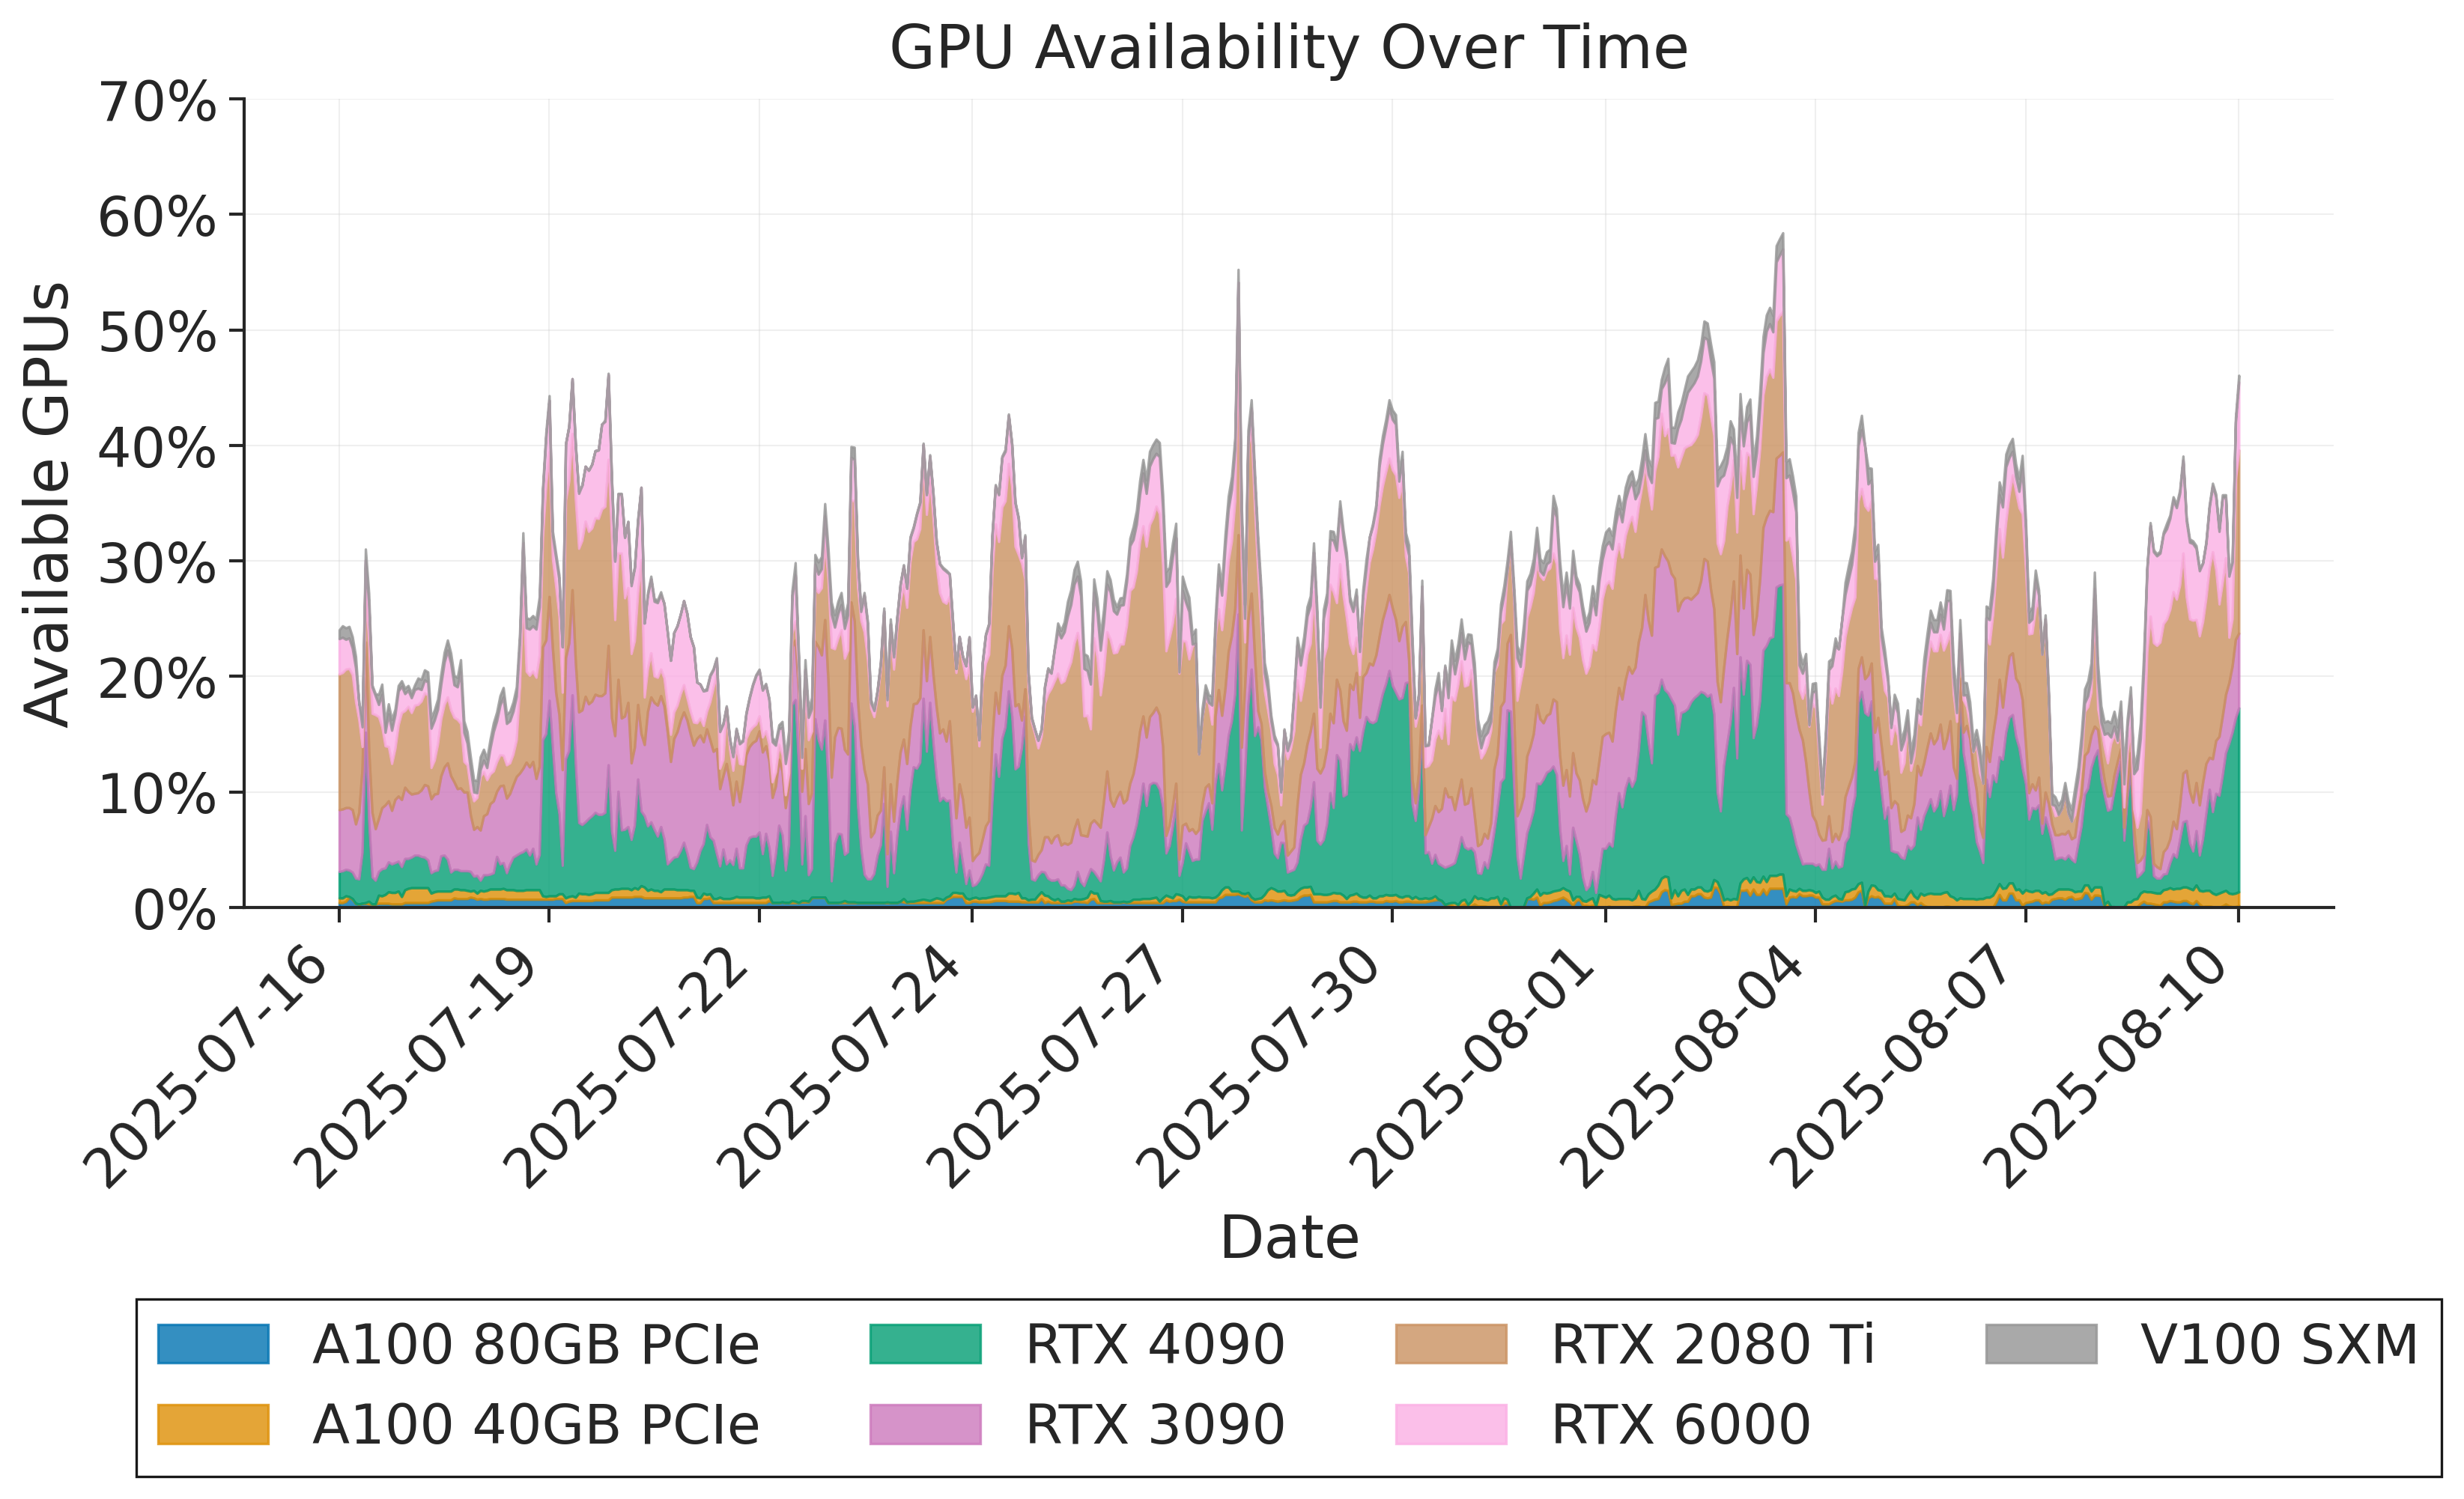

In [35]:
from matplotlib.ticker import PercentFormatter

# Stacking order: small dedicated GPUs at the bottom, large consumer cards in the middle, legacy V100 on top.
gpu_columns = [
    "nvidia_a100_80gb_pcie",
    "nvidia_a100-pcie-40gb",
    "nvidia_geforce_rtx_4090",
    "nvidia_geforce_rtx_3090",
    "nvidia_geforce_rtx_2080_ti",
    "quadro_rtx_6000",
    "tesla_v100-sxm2-32gb",
]
label_map = {
    "nvidia_a100_80gb_pcie": "A100 80GB PCIe",
    "nvidia_a100-pcie-40gb": "A100 40GB PCIe",
    "nvidia_geforce_rtx_4090": "RTX 4090",
    "nvidia_geforce_rtx_3090": "RTX 3090",
    "nvidia_geforce_rtx_2080_ti": "RTX 2080 Ti",
    "quadro_rtx_6000": "RTX 6000",
    "tesla_v100-sxm2-32gb": "V100 SXM",
}

fig, ax = pu.create_figure(
    format_type="double_column_wide",
    figsize=(12, 9),
    constrained_layout=False,
)
pu.plot_gpu_utilization_area(
    df=wide,
    time_col="Datetime",
    gpu_columns=gpu_columns,
    ax=ax,
    label_formatter=lambda c: label_map.get(c, c),
    title="GPU Availability Over Time",
    xlabel="Date",
    ylabel="Available GPUs",
    legend_ncol=4,
    legend_offset=-0.45,
    subplot_bottom_base=0.28,
)

# Each layer is a fraction of cluster capacity, so the stack lives in [0, 1];
# render as percent for a more legible y-axis.
ax.set_ylim(0, 0.7)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

fig_dir = Path("figure")
fig_dir.mkdir(exist_ok=True)
pu.save_figure(fig, str(fig_dir / "gpu_availability"), formats=["pdf"])
plt.show()